# Supervisionado x Não supervisionado
### O mesmo dataset, duas perguntas diferentes

Uma plataforma de streaming tem uma base de clientes. Sobre cada um sabemos:

- **nome**, **idade**, **profissão** — cadastro
- **histórico** — os filmes que a pessoa assistiu (comportamento)
- **filme favorito** — o que a pessoa *declarou* no cadastro (alguém escreveu isto)

Vamos fazer duas perguntas a esta mesma base:

| | Pergunta | Tipo |
|---|---|---|
| **Parte 1** | Dado idade e profissão, qual o filme favorito desta pessoa? | **Supervisionado** |
| **Parte 2** | Que grupos de gosto existem na minha base? | **Não supervisionado** |
| **Parte 3** | Chegou um filme novo. Para quem eu recomendo? | *as duas respondem?* |

> O foco de hoje **não são os algoritmos**. Os dois que vamos usar são os mais simples que existem, e ambos funcionam pela mesma ideia: **coisas parecidas ficam perto umas das outras**. O que muda entre eles é apenas uma coisa — se existe ou não um rótulo.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans

pd.set_option("display.max_columns", 20)

## Os dados

Dados **fictícios**, fabricados por nós. Isso é importante e vamos voltar a esse ponto no fim: nós plantamos o padrão aqui dentro, então o modelo vai encontrá-lo. Dados reais não são tão gentis.

A célula abaixo só fabrica a base — **não precisa entender esta célula.**

In [2]:
rng = np.random.default_rng(7)

# Cada filme descrito por 3 características, numa escala de 0 a 1
FILMES = {
    "Tropa de Elite":       {"acao": 0.9, "comedia": 0.0, "nacional": 1.0},
    "Rambo":                {"acao": 1.0, "comedia": 0.0, "nacional": 0.0},
    "Barbie":               {"acao": 0.2, "comedia": 0.8, "nacional": 0.0},
    "Minha Mãe é uma Peça": {"acao": 0.0, "comedia": 1.0, "nacional": 1.0},
}
TITULOS = list(FILMES)

# Probabilidade de assistir cada filme, conforme o gosto predominante da pessoa
PREF = {
    "Tropa de Elite":       [0.64, 0.18, 0.04, 0.14],
    "Rambo":                [0.18, 0.64, 0.12, 0.06],
    "Barbie":               [0.04, 0.12, 0.66, 0.18],
    "Minha Mãe é uma Peça": [0.14, 0.05, 0.17, 0.64],
}

PROFISSOES = ["Estudante", "Analista de TI", "Professor(a)", "Segurança", "Motorista", "Aposentado(a)"]
PESO_PROF = {
    "Segurança":      [7.0, 1.8, 0.15, 0.5],
    "Estudante":      [0.5, 0.4, 5.0, 0.9],
    "Motorista":      [0.9, 4.5, 0.35, 0.9],
    "Professor(a)":   [0.5, 0.3, 1.2, 4.5],
    "Aposentado(a)":  [0.6, 1.8, 0.3, 3.2],
    "Analista de TI": [2.4, 1.5, 1.1, 0.8],
}

def peso_gosto(idade, profissao):
    w = np.array([1.0, 1.0, 1.0, 1.0])
    if idade < 28:     w *= [0.5, 0.4, 4.0, 0.7]
    elif idade < 45:   w *= [2.6, 1.5, 0.8, 1.0]
    else:              w *= [0.7, 2.4, 0.25, 2.8]
    w *= PESO_PROF[profissao]
    return w / w.sum()

NOMES  = ["Ana","Bruno","Carla","Daniel","Elaine","Fábio","Gabriela","Henrique","Isabela","João",
          "Karina","Lucas","Mariana","Nelson","Patrícia","Rafael","Sandra","Thiago","Vanessa","Wagner",
          "Beatriz","Caio","Débora","Eduardo","Fernanda","Gustavo","Helena","Igor","Juliana","Kleber"]
SOBRE  = ["Silva","Souza","Costa","Lima","Rocha","Alves","Pinto","Moraes"]

linhas = []
for i in range(120):
    idade     = int(rng.integers(18, 66))
    profissao = str(rng.choice(PROFISSOES))
    gosto     = str(rng.choice(TITULOS, p=peso_gosto(idade, profissao)))   # gosto real, invisível
    historico = list(rng.choice(TITULOS, size=3, replace=True, p=PREF[gosto]))
    favorito  = gosto if rng.random() < 0.88 else str(rng.choice([t for t in TITULOS if t != gosto]))
    linhas.append({
        "nome": f"{NOMES[i % 30]} {SOBRE[i % 8]}",
        "idade": idade,
        "profissao": profissao,
        "historico": historico,
        "filme_favorito": favorito,
    })

clientes = pd.DataFrame(linhas)
print(clientes.shape)
clientes.head(10)

(120, 5)


,nome,idade,profissao,historico,filme_favorito
0,Ana Silva,63,Segurança,"[Minha Mãe é uma Peça, Barbie, Barbie]",Minha Mãe é uma Peça
1,Bruno Souza,61,Estudante,"[Minha Mãe é uma Peça, Minha Mãe é uma Peça, B...",Minha Mãe é uma Peça
2,Carla Costa,52,Analista de TI,"[Rambo, Rambo, Minha Mãe é uma Peça]",Rambo
3,Daniel Lima,51,Segurança,"[Barbie, Rambo, Minha Mãe é uma Peça]",Minha Mãe é uma Peça
4,Elaine Rocha,39,Estudante,"[Barbie, Minha Mãe é uma Peça, Barbie]",Barbie
5,Fábio Alves,30,Professor(a),"[Tropa de Elite, Barbie, Barbie]",Barbie
6,Gabriela Pinto,52,Professor(a),"[Barbie, Tropa de Elite, Tropa de Elite]",Rambo
7,Henrique Moraes,42,Aposentado(a),"[Minha Mãe é uma Peça, Tropa de Elite, Minha M...",Minha Mãe é uma Peça
8,Isabela Silva,58,Segurança,"[Tropa de Elite, Tropa de Elite, Tropa de Elite]",Tropa de Elite
9,João Souza,59,Analista de TI,"[Minha Mãe é uma Peça, Minha Mãe é uma Peça, M...",Minha Mãe é uma Peça


Olhem as colunas com atenção, porque a diferença da aula inteira está aqui:

- `nome` — **identificador**, não é característica. Ninguém gosta de um filme *porque* se chama Ana. Isto sai do modelo.
- `idade`, `profissao` — **características** (*features*): o que descreve a pessoa.
- `filme_favorito` — **rótulo** (*label*): a resposta certa, que **alguém preencheu**.
- `historico` — **comportamento**: o que a pessoa fez. Ninguém escreveu rótulo nenhum aqui.

In [3]:
# Quantos clientes de cada filme favorito? (Vai importar daqui a pouco.)
clientes["filme_favorito"].value_counts()

filme_favorito
Minha Mãe é uma Peça    42
Rambo                   32
Barbie                  23
Tropa de Elite          23
Name: count, dtype: int64

---
# Parte 1 — Supervisionado
## "Dado idade e profissão, qual o filme favorito?"

Supervisionado = **eu tenho a resposta certa para os casos passados** e quero prevê-la para os casos novos.

Modelo: **k-NN** (*k-nearest neighbors*, k vizinhos mais próximos). A ideia inteira dele cabe numa frase:

> *Para adivinhar o filme de uma pessoa nova, olhe as **k pessoas mais parecidas** com ela na base e veja qual filme a maioria delas escolheu.*

In [4]:
# X = o que o modelo pode olhar.  y = o que ele deve prever.
X = pd.get_dummies(clientes[["idade", "profissao"]], columns=["profissao"])
y = clientes["filme_favorito"]

X.head(3)

,idade,profissao_Analista de TI,profissao_Aposentado(a),profissao_Estudante,profissao_Motorista,profissao_Professor(a),profissao_Segurança
0,63,False,False,False,False,False,True
1,61,False,False,True,False,False,False
2,52,True,False,False,False,False,False


`profissao` virou 6 colunas de 0 e 1 — o modelo calcula **distância**, e não dá para subtrair "Motorista" de "Estudante". Isto se chama *one-hot encoding*.

E logo abaixo: separamos os dados em **treino** e **teste**. O modelo aprende com o treino e é avaliado no teste — dados que ele nunca viu. Avaliar no que já foi visto é colar na prova.

In [5]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

modelo = make_pipeline(
    StandardScaler(),                     # coloca idade e as colunas 0/1 na mesma escala
    KNeighborsClassifier(n_neighbors=5)   # k = 5 vizinhos
)
modelo.fit(X_treino, y_treino)

acerto   = modelo.score(X_teste, y_teste)
chute    = y_teste.value_counts(normalize=True).max()

print(f"Acerto do modelo : {acerto:.1%}")
print(f"Chutando sempre o filme mais comum: {chute:.1%}")

Acerto do modelo : 63.9%
Chutando sempre o filme mais comum: 36.1%


Melhor que chutar — e longe de perfeito. Guardem essa sensação: **isto é o normal**. Idade e profissão dizem *alguma coisa* sobre gosto de filme, não dizem tudo.

In [6]:
# Um cliente novo chega. O modelo responde na hora.
# >>> MEXA AQUI AO VIVO: mude a idade e a profissão e rode de novo.
novo_cliente = pd.DataFrame([{"idade": 52, "profissao": "Segurança"}])

novo_X = pd.get_dummies(novo_cliente, columns=["profissao"]).reindex(columns=X.columns, fill_value=0)

print("Previsão:", modelo.predict(novo_X)[0])
print()
print("Confiança em cada filme (proporção dos 5 vizinhos):")
pd.Series(modelo.predict_proba(novo_X)[0], index=modelo.classes_).sort_values(ascending=False)

Previsão: Rambo

Confiança em cada filme (proporção dos 5 vizinhos):


Rambo                   0.8
Tropa de Elite          0.2
Barbie                  0.0
Minha Mãe é uma Peça    0.0
dtype: float64

In [7]:
# Onde ele acerta e onde ele erra
previsto = modelo.predict(X_teste)
pd.crosstab(y_teste, previsto, rownames=["Favorito real"], colnames=["Previsto"])

Previsto,Barbie,Minha Mãe é uma Peça,Rambo,Tropa de Elite
Favorito real,,,,
Barbie,3,1,1,2
Minha Mãe é uma Peça,0,10,2,1
Rambo,0,4,5,0
Tropa de Elite,1,0,1,5


### O que o supervisionado exigiu de nós

Alguém, em algum momento, **preencheu o campo "filme favorito"** para 120 clientes. Sem essa coluna, nada disto existe.

Essa é a conta que o supervisionado sempre cobra: **rótulo custa trabalho humano.** Em segurança pública, "esta ocorrência foi fraude / não foi" é alguém que classificou, um a um.

E guardem esta segunda restrição, que vai voltar na Parte 3: o modelo só sabe responder **quatro coisas** — os quatro filmes que viu no treino.

In [8]:
modelo.classes_

array(['Barbie', 'Minha Mãe é uma Peça', 'Rambo', 'Tropa de Elite'],
      dtype=object)

---
# Parte 2 — Não supervisionado
## "Que grupos de gosto existem na minha base?"

Agora **jogamos o rótulo fora.** Ninguém preencheu nada. Só temos o que as pessoas assistiram.

A pergunta muda de natureza: não existe resposta certa para conferir. A pergunta agora é **"o que há aqui dentro?"**

Primeiro precisamos descrever cada cliente por seu **gosto**, e não por seu cadastro. O truque: descrever cada filme por características, e o cliente pela **média dos filmes que assistiu**.

In [9]:
CARACTERISTICAS = ["acao", "comedia", "nacional"]
tabela_filmes = pd.DataFrame(FILMES).T[CARACTERISTICAS]
tabela_filmes

,acao,comedia,nacional
Tropa de Elite,0.9,0.0,1.0
Rambo,1.0,0.0,0.0
Barbie,0.2,0.8,0.0
Minha Mãe é uma Peça,0.0,1.0,1.0


In [10]:
def perfil_de_gosto(historico):
    tags = [[FILMES[f][c] for c in CARACTERISTICAS] for f in historico]
    return pd.Series(np.mean(tags, axis=0), index=CARACTERISTICAS)

perfis = clientes["historico"].apply(perfil_de_gosto)

pd.concat([clientes[["nome", "historico"]], perfis.round(2)], axis=1).head(8)

,nome,historico,acao,comedia,nacional
0,Ana Silva,"[Minha Mãe é uma Peça, Barbie, Barbie]",0.13,0.87,0.33
1,Bruno Souza,"[Minha Mãe é uma Peça, Minha Mãe é uma Peça, B...",0.07,0.93,0.67
2,Carla Costa,"[Rambo, Rambo, Minha Mãe é uma Peça]",0.67,0.33,0.33
3,Daniel Lima,"[Barbie, Rambo, Minha Mãe é uma Peça]",0.40,0.60,0.33
4,Elaine Rocha,"[Barbie, Minha Mãe é uma Peça, Barbie]",0.13,0.87,0.33
5,Fábio Alves,"[Tropa de Elite, Barbie, Barbie]",0.43,0.53,0.33
6,Gabriela Pinto,"[Barbie, Tropa de Elite, Tropa de Elite]",0.67,0.27,0.67
7,Henrique Moraes,"[Minha Mãe é uma Peça, Tropa de Elite, Minha M...",0.30,0.67,1.00


Agora cada cliente é um **ponto num espaço de gosto** de 3 dimensões. E — este é o ponto que faz a Parte 3 funcionar — **os filmes vivem nesse mesmo espaço**, descritos pelas mesmas 3 características.

Modelo: **K-means**. Outra frase só:

> *Escolha k grupos; o algoritmo acha o centro de cada um e coloca cada pessoa no centro mais próximo.*

⚠️ **Cuidado com o nome.** k-NN e K-means são coisas diferentes, e o "k" quer dizer coisas diferentes:
> - **k-NN** (supervisionado): k = **quantos vizinhos votam**.
> - **K-means** (não supervisionado): k = **quantos grupos existem**.

In [27]:
# >>> MEXA AQUI AO VIVO: troque k para 2, 3, 5... Quem manda no k é você, não o algoritmo.
k = 4

agrupador = KMeans(n_clusters=k, n_init=10, random_state=42)
clientes["grupo"] = agrupador.fit_predict(perfis)

centros = pd.DataFrame(agrupador.cluster_centers_, columns=CARACTERISTICAS)
centros.index.name = "grupo"
print("Quantos clientes em cada grupo:", clientes["grupo"].value_counts().sort_index().to_dict())
centros.round(2)

Quantos clientes em cada grupo: {0: 36, 1: 40, 2: 23, 3: 21}


,acao,comedia,nacional
grupo,,,
0,0.90,0.09,0.17
1,0.19,0.80,0.87
2,0.25,0.74,0.16
3,0.78,0.15,0.79


Leiam a tabela dos centros como um retrato falado de cada grupo: um com ação alta e comédia zero, outro com comédia alta e nacional alto, etc.

**Os grupos não vêm com nome.** O algoritmo devolve "grupo 0", "grupo 1". Quem olha os números e diz *"este é o grupo da ação nacional"* é **você**. Essa parte não é automática, e não é detalhe: é onde entra o conhecimento de quem conhece o domínio.

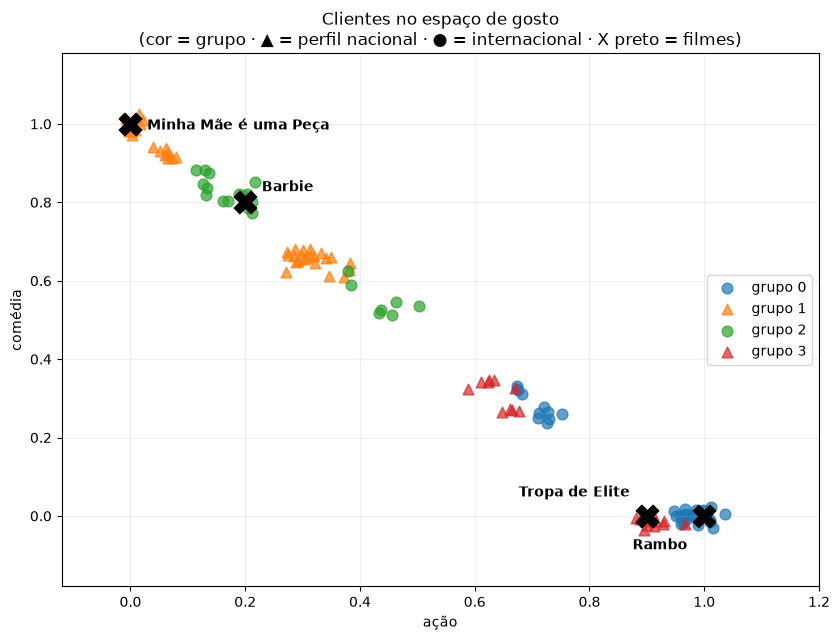

In [28]:
fig, ax = plt.subplots(figsize=(8.5, 6.5))

rng_plot = np.random.default_rng(1)
jitter = lambda v: v + rng_plot.normal(0, 0.018, len(v))

for g in sorted(clientes["grupo"].unique()):
    ja_rotulado = False
    for nac, marcador in [(False, "o"), (True, "^")]:
        m = (clientes["grupo"] == g) & ((perfis["nacional"] >= 0.5) == nac)
        if not m.any():
            continue
        ax.scatter(jitter(perfis.loc[m, "acao"]), jitter(perfis.loc[m, "comedia"]),
                   marker=marcador, s=60, alpha=0.7, color=plt.cm.tab10(g),
                   label=(f"grupo {g}" if not ja_rotulado else None))
        ja_rotulado = True

POSICAO_TEXTO = {
    "Tropa de Elite":       ((-12, 14), "right"),
    "Rambo":                ((-12, -24), "right"),
    "Barbie":               ((12, 8), "left"),
    "Minha Mãe é uma Peça": ((12, -4), "left"),
}
for titulo, row in tabela_filmes.iterrows():
    desloc, alinha = POSICAO_TEXTO[titulo]
    ax.scatter(row["acao"], row["comedia"], marker="X", s=260, color="black", zorder=5)
    ax.annotate(titulo, (row["acao"], row["comedia"]), textcoords="offset points",
                xytext=desloc, ha=alinha, fontsize=10, weight="bold", zorder=6)

ax.set_xlim(-0.12, 1.2); ax.set_ylim(-0.18, 1.18)
ax.set_xlabel("ação"); ax.set_ylabel("comédia")
ax.set_title("Clientes no espaço de gosto\n(cor = grupo · ▲ = perfil nacional · ● = internacional · X preto = filmes)")
ax.legend(loc="center right"); ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()

Uma pergunta que sempre aparece aqui: **por que existem dois grupos ocupando o mesmo canto do gráfico?**

Porque o gráfico é plano e o espaço de gosto tem **três** dimensões. No eixo ação e no eixo comédia esses dois grupos são idênticos — o que os separa é a terceira característica, `nacional`, que aqui virou o **formato do ponto** (▲ nacional, ● internacional).

É um problema geral e vai reaparecer na disciplina: o algoritmo trabalha em quantas dimensões você quiser, e nós só enxergamos duas.

### O teste honesto

O agrupamento **nunca viu** a coluna `filme_favorito`. Vamos espiar se ele chegou perto dela sozinho:

In [29]:
pd.crosstab(clientes["grupo"], clientes["filme_favorito"])

filme_favorito,Barbie,Minha Mãe é uma Peça,Rambo,Tropa de Elite
grupo,,,,
0,3,2,26,5
1,5,31,0,4
2,14,7,1,1
3,1,2,5,13


Cada grupo concentra fortemente um favorito — **sem nunca ter visto o rótulo.** Só a partir do que as pessoas assistiram.

Mas atenção a como isso deve ser lido: o algoritmo **não redescobriu os filmes**. Ele achou *regiões de gosto*, e acontece que nesta base fictícia cada região é dominada por um filme. Em dados reais os grupos raramente coincidem com algo que você já tinha nomeado — e é justamente por isso que eles são úteis.

---
# Parte 3 — Chegou um filme novo
## Para quem eu recomendo?

O catálogo recebeu **Cidade de Deus**. Nenhum cliente da base assistiu. Nenhum cliente tem isso como favorito.

Façamos a mesma pergunta aos dois lados da aula.

In [30]:
# Descrevemos o filme novo com as MESMAS 3 características
filme_novo = {"titulo": "Cidade de Deus", "acao": 0.8, "comedia": 0.0, "nacional": 1.0}

vetor = np.array([filme_novo[c] for c in CARACTERISTICAS])
distancias = np.linalg.norm(agrupador.cluster_centers_ - vetor, axis=1)

resultado = centros.round(2).copy()
resultado["distancia_ao_filme"] = distancias.round(2)
resultado["clientes"] = clientes["grupo"].value_counts().sort_index()
resultado.sort_values("distancia_ao_filme")

,acao,comedia,nacional,distancia_ao_filme,clientes
grupo,,,,,
3,0.78,0.15,0.79,0.25,21
0,0.90,0.09,0.17,0.84,36
1,0.19,0.80,0.87,1.01,40
2,0.25,0.74,0.16,1.25,23


In [31]:
grupo_alvo = int(distancias.argmin())
alvo = clientes[clientes["grupo"] == grupo_alvo]

print(f"'{filme_novo['titulo']}' cai no grupo {grupo_alvo} — {len(alvo)} clientes para notificar.\n")
print("Favorito declarado por quem caiu nesse grupo:")
print(alvo["filme_favorito"].value_counts().to_string())
print()
alvo[["nome", "idade", "profissao", "filme_favorito"]].head(8)

'Cidade de Deus' cai no grupo 3 — 21 clientes para notificar.

Favorito declarado por quem caiu nesse grupo:
filme_favorito
Tropa de Elite          13
Rambo                    5
Minha Mãe é uma Peça     2
Barbie                   1



,nome,idade,profissao,filme_favorito
6,Gabriela Pinto,52,Professor(a),Rambo
8,Isabela Silva,58,Segurança,Tropa de Elite
13,Nelson Alves,49,Analista de TI,Rambo
16,Sandra Silva,52,Professor(a),Rambo
30,Ana Pinto,56,Motorista,Rambo
33,Daniel Souza,25,Segurança,Tropa de Elite
40,Karina Silva,49,Aposentado(a),Minha Mãe é uma Peça
58,Juliana Costa,42,Estudante,Tropa de Elite


Agora a mesma pergunta para o modelo supervisionado.

In [32]:
print("O que o modelo supervisionado é capaz de responder:")
print(modelo.classes_)
print()
print("'Cidade de Deus' está nessa lista?", "Cidade de Deus" in modelo.classes_)

O que o modelo supervisionado é capaz de responder:
['Barbie' 'Minha Mãe é uma Peça' 'Rambo' 'Tropa de Elite']

'Cidade de Deus' está nessa lista? False


**Ele não consegue.** Não é limitação de código nem falta de dados suficientes: o modelo supervisionado só sabe devolver **rótulos que alguém escreveu antes**. Filme novo = rótulo que não existe = é preciso rotular clientes de novo e **retreinar**.

O não supervisionado respondeu sem retreinar nada, porque ele nunca dependeu de rótulo nenhum — só de **semelhança**.

In [33]:
# E quando o filme novo não é tão bem comportado?
# Deadpool: ação alta E comédia alta, internacional.
outro = np.array([0.9, 0.8, 0.0])
d = np.linalg.norm(agrupador.cluster_centers_ - outro, axis=1)

pd.DataFrame({"distancia": d.round(2)}, index=centros.index).sort_values("distancia")

,distancia
grupo,
2,0.67
0,0.73
3,1.03
1,1.12


Reparem: aqui os dois primeiros grupos estão **quase empatados**. O método não devolve certeza — devolve **proximidade**. Quando a distância empata, a decisão volta para a mesa de alguém.

---
# Fechando

| | Supervisionado | Não supervisionado |
|---|---|---|
| **Pergunta** | Qual o rótulo deste caso? | O que existe dentro destes dados? |
| **Precisa de** | Alguém que escreveu a resposta certa | Só o que foi observado |
| **O que devolve** | Um dos rótulos conhecidos | Grupos sem nome |
| **Como se avalia** | Comparando com a resposta certa | Não há resposta certa para conferir — você julga se é útil |
| **Caso novo (fora dos rótulos)** | Não responde: tem que rotular e retreinar | Responde, por semelhança |
| **Quem nomeia o resultado** | Já vem nomeado | **Você** |
| **Modelo de hoje** | k-NN (k = vizinhos que votam) | K-means (k = grupos que existem) |

**Uma honestidade para levar daqui:** estes dados são fabricados. Nós plantamos o padrão — por isso os grupos saíram tão limpos e o modelo funcionou. Dados reais vêm com campo em branco, rótulo preenchido de qualquer jeito e grupo que não quer dizer nada. É disso que trata o resto da disciplina.

### Para mexer ao vivo
1. `n_neighbors` no k-NN: 1, 5, 25. Com k = 1 ele decora; com k = 25 ele alisa tudo.
2. `k` no K-means: 2, 3, 5. Repare que **nenhum** valor dá erro — o algoritmo obedece. Escolher k é decisão sua.
3. Mude `novo_cliente` para alguém de 20 anos, Estudante.
4. Invente um filme novo em `filme_novo` e veja em que grupo ele cai.